In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
df = pd.read_csv("Cleaned_Sales_dataSet.csv")
df.head()

,transaction_id,customer_id,category,item,price_per_unit,quantity,total_spent,payment_method,location,date,discount_applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,Unknown
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11362 entries, 0 to 11361
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_id    11362 non-null  str    
 1   customer_id       11362 non-null  str    
 2   category          11362 non-null  str    
 3   item              11362 non-null  str    
 4   price_per_unit    11362 non-null  float64
 5   quantity          11362 non-null  float64
 6   total_spent       11362 non-null  float64
 7   payment_method    11362 non-null  str    
 8   location          11362 non-null  str    
 9   date              11362 non-null  str    
 10  discount_applied  11362 non-null  str    
dtypes: float64(3), str(8)
memory usage: 976.6 KB


In [20]:
df.describe()

,price_per_unit,quantity,total_spent
count,11362.000000,11362.000000,11362.000000
mean,23.356847,5.535029,129.642537
std,10.736030,2.855166,94.662368
min,5.000000,1.000000,5.000000
25%,14.000000,3.000000,52.000000
50%,23.000000,6.000000,108.500000
75%,33.500000,8.000000,192.000000
max,41.000000,10.000000,410.000000


In [3]:
df.columns

Index(['transaction_id', 'customer_id', 'category', 'item', 'price_per_unit',
       'quantity', 'total_spent', 'payment_method', 'location', 'date',
       'discount_applied'],
      dtype='str')

In [4]:
df.dtypes


transaction_id          str
customer_id             str
category                str
item                    str
price_per_unit      float64
quantity            float64
total_spent         float64
payment_method          str
location                str
date                    str
discount_applied        str
dtype: object

In [5]:
df['category'].unique()
df['category'].value_counts()


category
Furniture                             1460
Electric household essentials         1437
Beverages                             1427
Food                                  1426
Milk Products                         1425
Butchers                              1421
Computers and electric accessories    1397
Patisserie                            1369
Name: count, dtype: int64

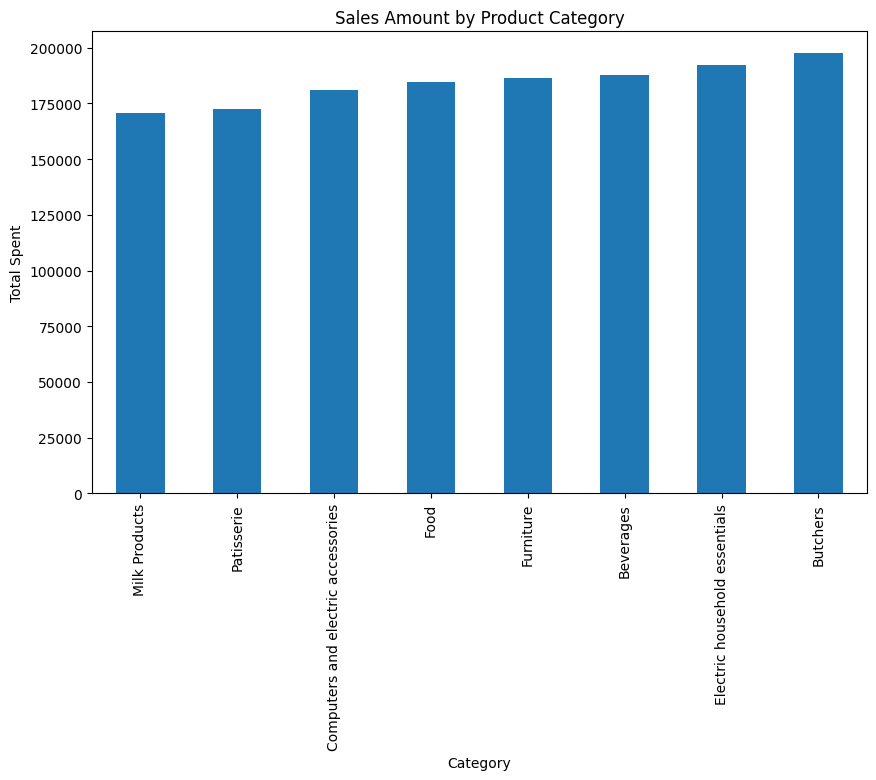

In [6]:

category_sales = df.groupby("category")["total_spent"].sum().sort_values()

category_sales.plot(
    kind="bar",
    figsize=(10,6),
    title="Sales Amount by Product Category"
)

plt.xlabel("Category")
plt.ylabel("Total Spent")
plt.show()


In [7]:
Total_Revenue = df["total_spent"].sum()
print(f"Total Revenue: ${Total_Revenue:,.2f}")

Total Revenue: $1,472,998.50


In [8]:
df['item'].unique()
df['item'].value_counts()

item
Item_2_BEV      126
Item_25_FUR     113
Item_11_FUR     110
Item_16_MILK    109
Item_1_MILK     109
               ... 
Item_13_BEV       7
Item_5_BEV        7
Item_13_FUR       7
Item_21_PAT       6
Item_3_EHE        5
Name: count, Length: 200, dtype: int64

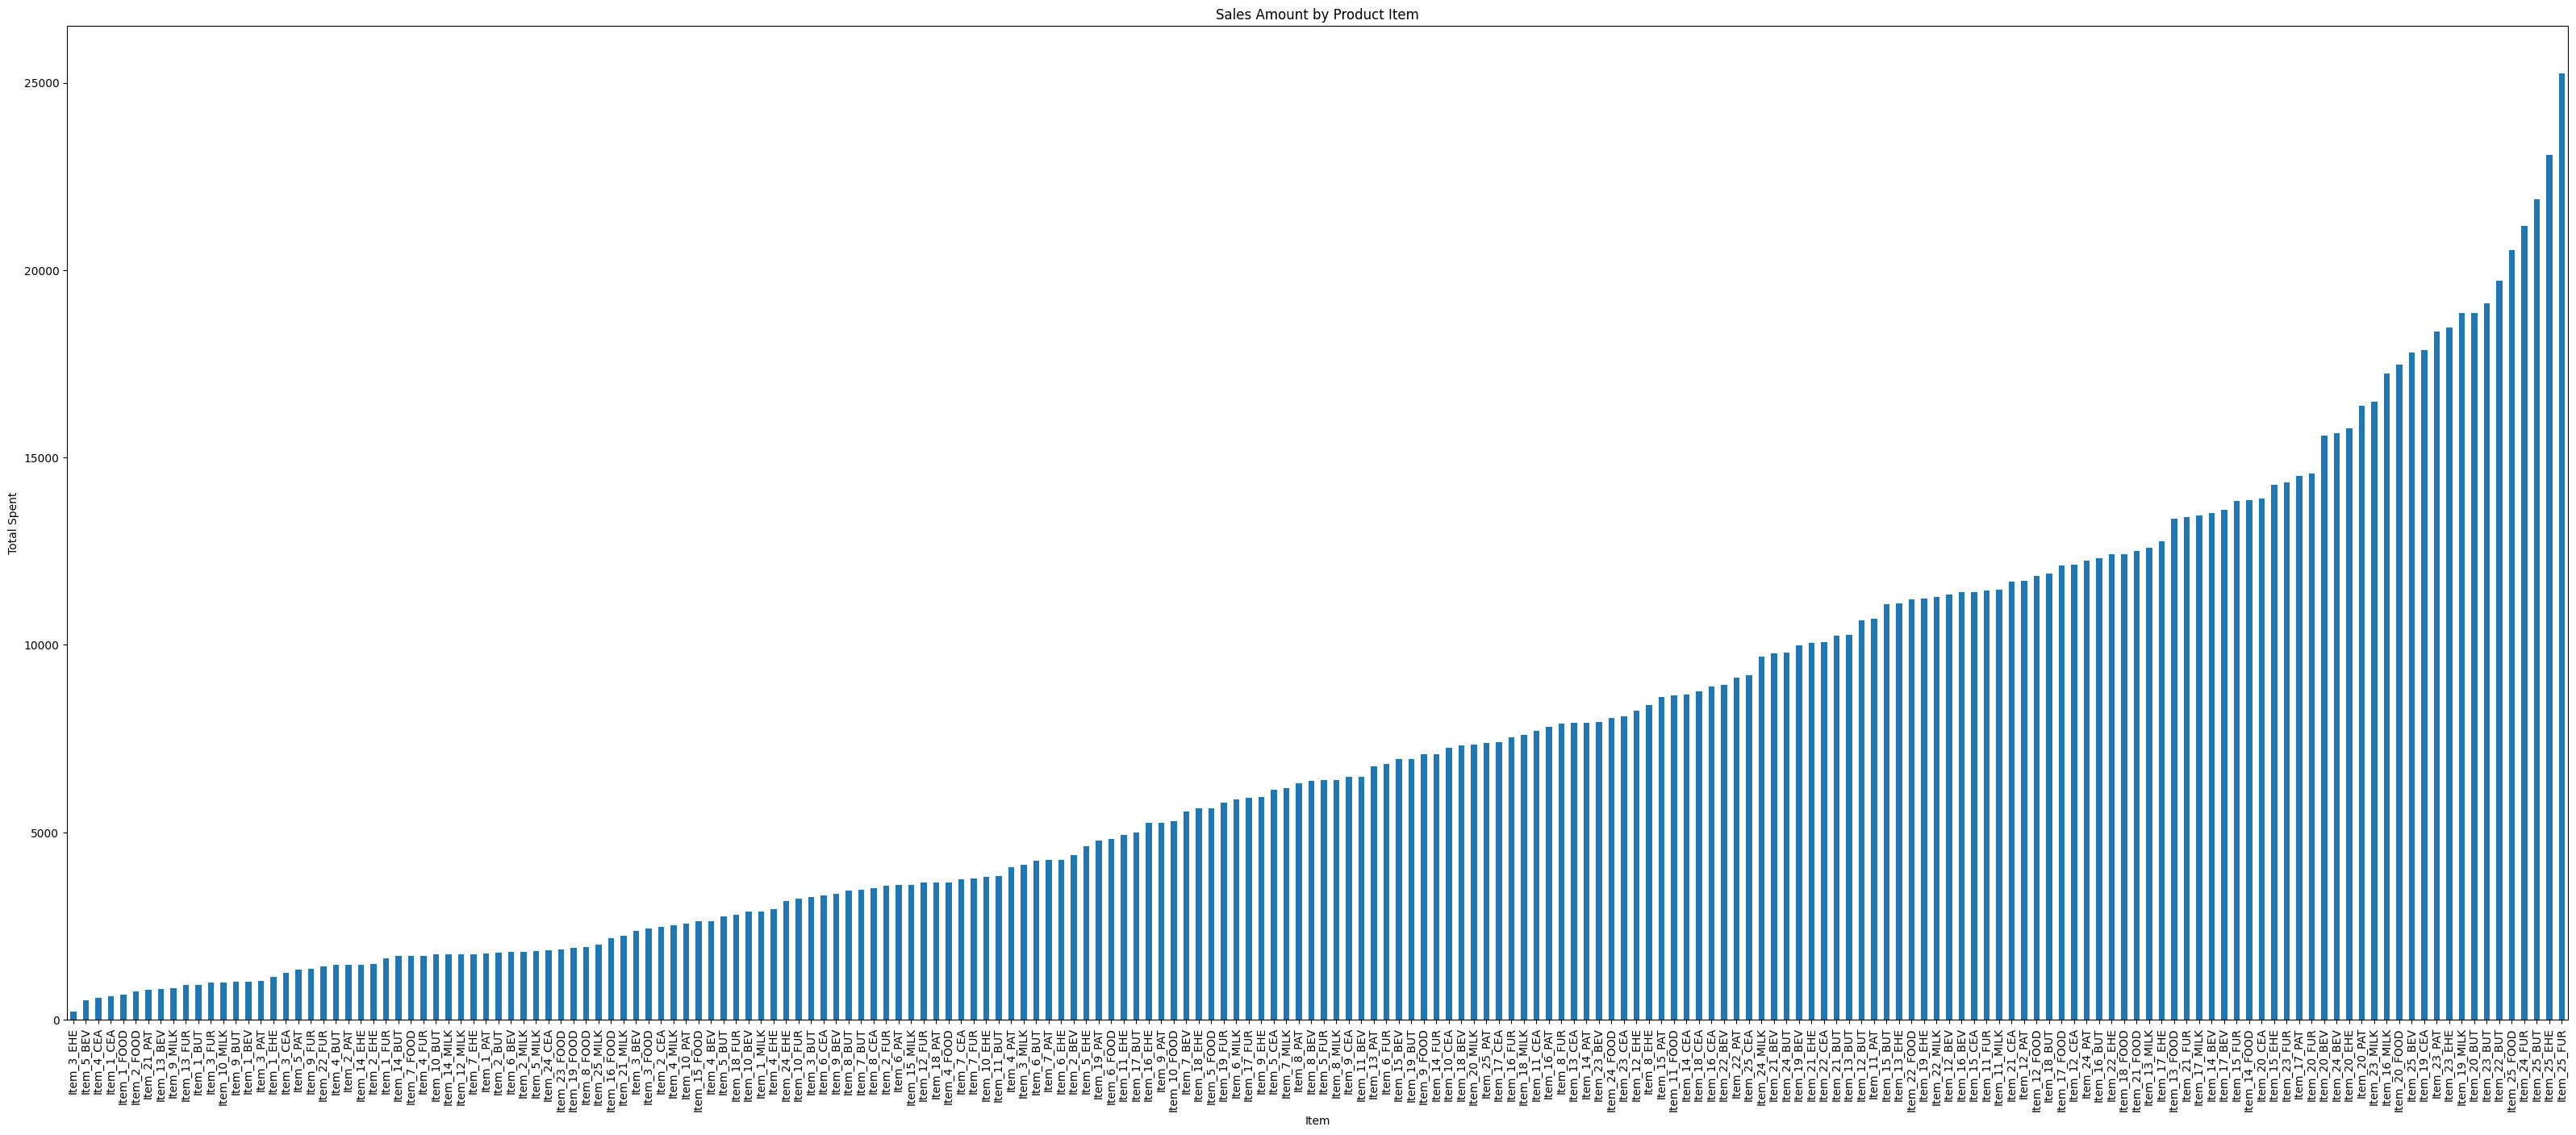

In [9]:
items_sales = df.groupby("item")["total_spent"].sum().sort_values()

items_sales.plot(
    kind="bar",
    figsize=(40,16),
    title="Sales Amount by Product Item"
)

plt.xticks(rotation=90)
plt.xlabel("Item")
plt.ylabel("Total Spent")
plt.show()


In [10]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')
dt = df['date'].dtype
print(dt)



datetime64[us]


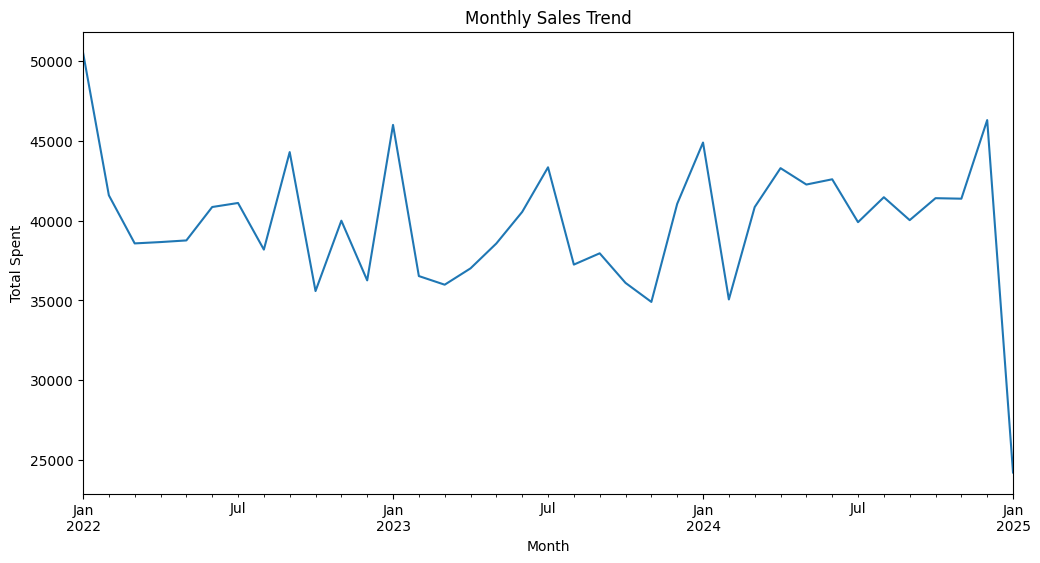

In [11]:
df.set_index('date', inplace=True)
monthly_sales = df.resample('ME')['total_spent'].sum()
monthly_sales.plot(
    kind='line',
    figsize=(12,6),
    title='Monthly Sales Trend'
)
plt.xlabel("Month")
plt.ylabel("Total Spent")
plt.show()

In [12]:
order_totals = df.groupby('transaction_id')['total_spent'].sum().mean()
print(f"Average Order Total: ${order_totals:,.2f}")

Average Order Total: $129.64


In [14]:
df.columns
df.head()

,transaction_id,customer_id,category,item,price_per_unit,quantity,total_spent,payment_method,location,discount_applied
date,,,,,,,,,,
2024-04-08,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,True
2023-07-23,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,True
2022-10-05,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,False
2022-05-07,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,Unknown
2022-10-02,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,False


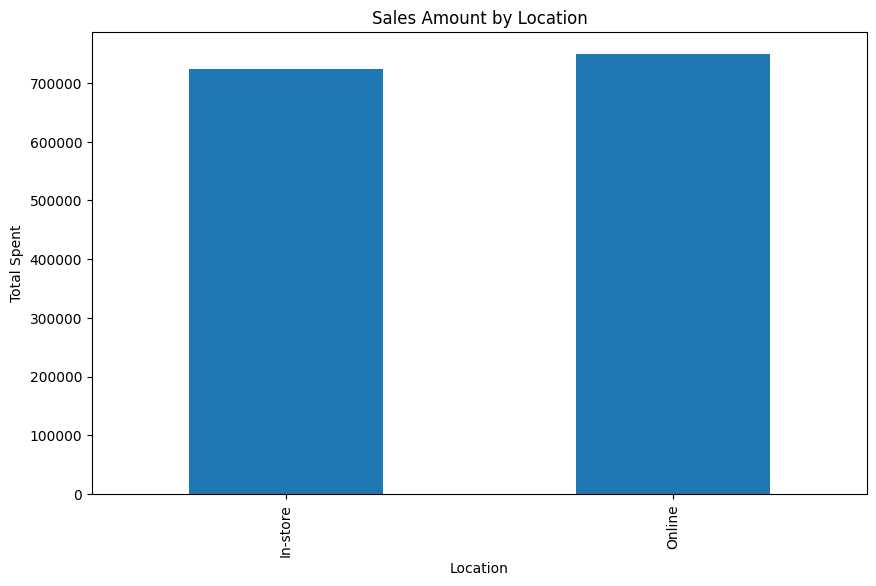

In [16]:
location_sales = df.groupby("location")["total_spent"].sum().sort_values()
location_sales.plot(
    kind="bar",
    figsize=(10,6),
    title="Sales Amount by Location"
)  
plt.xlabel("Location")
plt.ylabel("Total Spent")
plt.show()

In [21]:
df.columns

Index(['transaction_id', 'customer_id', 'category', 'item', 'price_per_unit',
       'quantity', 'total_spent', 'payment_method', 'location', 'date',
       'discount_applied'],
      dtype='str')

Average Sales with Discount: $130.72
Average Sales without Discount: $130.13

Total Sales with Discount: $496,880.50
Total Sales without Discount: $491,632.50


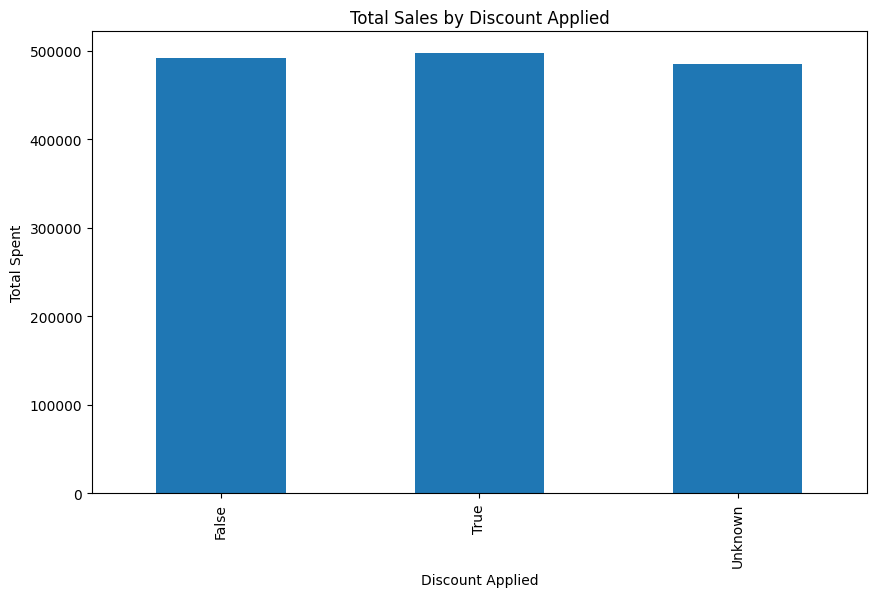

In [29]:
discount = df.groupby('discount_applied')['total_spent'].sum()
discountYes = df[df['discount_applied'] == 'True']['total_spent'].sum()
discountNo = df[df['discount_applied'] == 'False']['total_spent'].sum()
discountYesMean = df[df['discount_applied'] == 'True']['total_spent'].mean()
discountNoMean = df[df['discount_applied'] == 'False']['total_spent'].mean()

print(f"Average Sales with Discount: ${discountYesMean:,.2f}")
print(f"Average Sales without Discount: ${discountNoMean:,.2f}")

print(f"\nTotal Sales with Discount: ${discountYes:,.2f}")
print(f"Total Sales without Discount: ${discountNo:,.2f}")
discount.plot(
    kind="bar",
    figsize=(10,6),
    title="Total Sales by Discount Applied"
)
plt.xlabel("Discount Applied")
plt.ylabel("Total Spent")
plt.show()

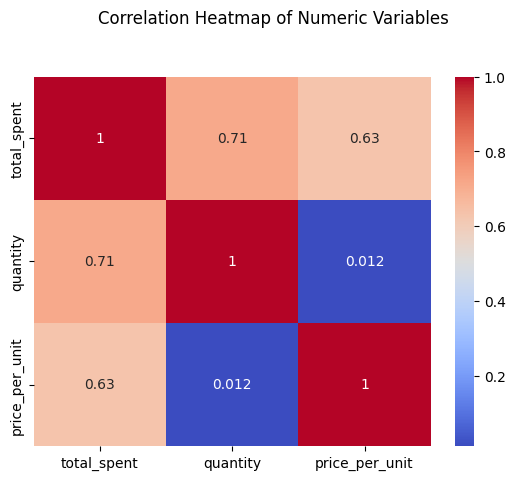

In [30]:
numeric_cols = df[['total_spent', 'quantity', 'price_per_unit']]
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm')
plt.suptitle("Correlation Heatmap of Numeric Variables", y=1.02)
plt.show()

In [35]:
co = df['customer_id'].value_counts()
cp1 = df['customer_id'].unique()
print(co)
print(cp1)

customer_id
CUST_05    497
CUST_13    491
CUST_24    489
CUST_08    480
CUST_15    478
CUST_16    469
CUST_09    465
CUST_01    461
CUST_10    458
CUST_20    457
CUST_22    456
CUST_11    453
CUST_12    452
CUST_23    450
CUST_02    447
CUST_14    447
CUST_18    447
CUST_21    447
CUST_06    443
CUST_25    438
CUST_07    433
CUST_19    431
CUST_04    428
CUST_03    423
CUST_17    422
Name: count, dtype: int64
<StringArray>
['CUST_09', 'CUST_22', 'CUST_02', 'CUST_06', 'CUST_05', 'CUST_07', 'CUST_23',
 'CUST_25', 'CUST_14', 'CUST_17', 'CUST_10', 'CUST_04', 'CUST_13', 'CUST_18',
 'CUST_08', 'CUST_12', 'CUST_15', 'CUST_11', 'CUST_19', 'CUST_16', 'CUST_24',
 'CUST_20', 'CUST_21', 'CUST_01', 'CUST_03']
Length: 25, dtype: str


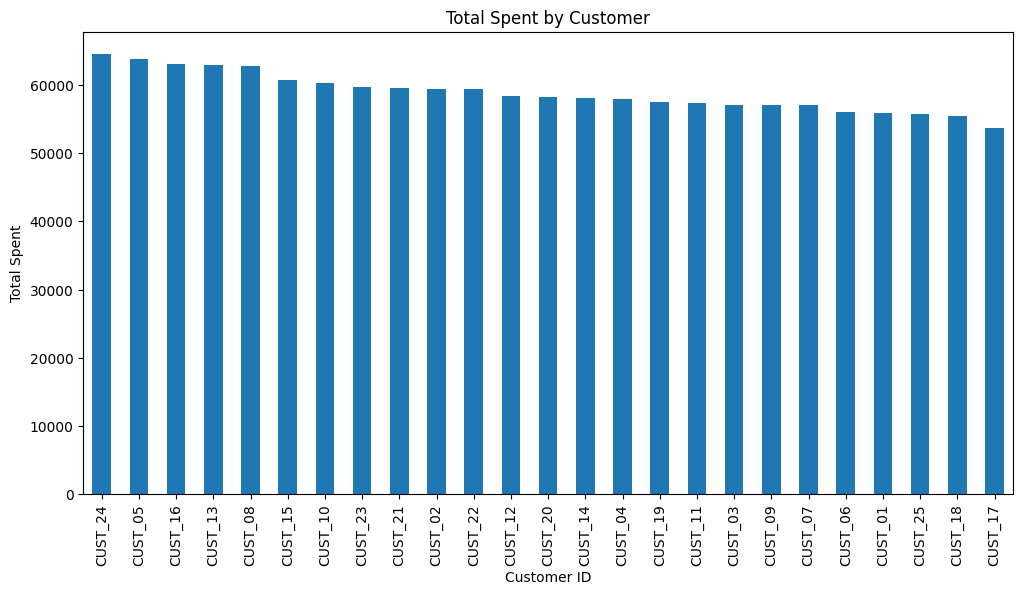

customer_id
CUST_24    64608.0
CUST_05    63855.5
CUST_16    63185.5
CUST_13    63015.5
CUST_08    62850.5
CUST_15    60749.5
CUST_10    60367.5
CUST_23    59738.5
CUST_21    59639.0
CUST_02    59512.5
Name: total_spent, dtype: float64

In [36]:
customer_value = df.groupby('customer_id')['total_spent'].sum().sort_values(ascending=False)
customer_value.plot(
    kind='bar',
    figsize=(12,6),
    title='Total Spent by Customer'
)
plt.xlabel("Customer ID")
plt.ylabel("Total Spent")
plt.show()

customer_value.head(10)

<Axes: xlabel='total_spent'>

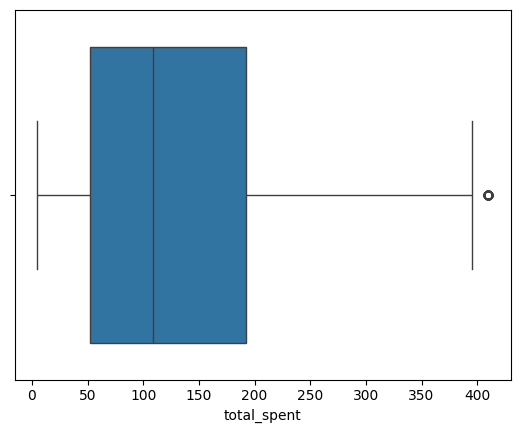

In [37]:
sns.boxplot(x=df['total_spent'])

<Axes: >

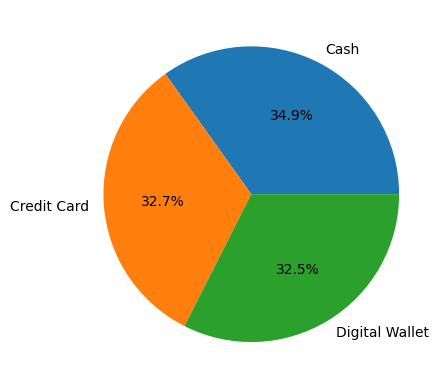

In [38]:
df.groupby('payment_method')['total_spent'].sum().plot(kind='pie', autopct='%1.1f%%')

In [42]:
print("Date ", df.index.min(), "to", df.index.max())
print("Total number of transactions:", len(df))
print("Unique payment methods:", df['payment_method'].unique())
print("Unique locations:", df['location'].unique())
print("Unique categories:", df['category'].unique())
print("Unique items:", df['item'].unique())
print("Number of unique customers:", df['customer_id'].nunique())
print("Average quantity sold per transaction:", df['quantity'].mean())
print("Average price per unit:", df['price_per_unit'].mean())
print("Average total spent per transaction:", df['total_spent'].mean())
print(f"Total Days covered: {df.index.max() - df.index.min()}")


Date  0 to 11361
Total number of transactions: 11362
Unique payment methods: <StringArray>
['Digital Wallet', 'Credit Card', 'Cash']
Length: 3, dtype: str
Unique locations: <StringArray>
['Online', 'In-store']
Length: 2, dtype: str
Unique categories: <StringArray>
[                        'Patisserie',                      'Milk Products',
                           'Butchers',                          'Beverages',
                               'Food',                          'Furniture',
      'Electric household essentials', 'Computers and electric accessories']
Length: 8, dtype: str
Unique items: <StringArray>
[ 'Item_10_PAT', 'Item_17_MILK',  'Item_12_BUT',  'Item_16_BEV',
  'Item_6_FOOD',  'Item_1_FOOD',  'Item_16_FUR',  'Item_22_BUT',
   'Item_3_BUT',  'Item_2_FOOD',
 ...
   'Item_3_PAT',  'Item_13_FUR',  'Item_18_PAT', 'Item_12_MILK',
 'Item_10_MILK', 'Item_16_FOOD', 'Item_19_FOOD',  'Item_14_EHE',
   'Item_3_EHE',   'Item_9_BUT']
Length: 200, dtype: str
Number of unique custo